# Exploratory Data Analysis
This notebook focuses on understanding the raw dataset and the main data patterns. It avoids preprocessing and modeling steps so the analysis remains clear and focused.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style='whitegrid', palette='muted')


In [3]:
data = pd.read_csv('../data/raw/global_graduate_employability_index.csv')
data.head()


,Country,Region,University_Name,Degree_Level,Field_of_Study,Graduation_Year,Employment_Rate_6_Months (%),Employment_Rate_12_Months (%),Average_Starting_Salary_USD,Top_Industry,Job_Role,Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1–100),Remote_Work_Availability (%),Employer_Reputation_Score (1–100),Year
0,USA,North America,Harvard,Bachelor,Engineering,2017,79.3,85.6,66700,Manufacturing/Construction,Robotics Engineer,AutoCAD,Lean Six Sigma,MATLAB,69,8.8,66,2017
1,USA,North America,MIT,Bachelor,Engineering,2023,83.8,87.9,84500,Manufacturing/Construction,Civil Engineer,Lean Six Sigma,AutoCAD,MATLAB,71,65.4,63,2023
2,Israel,Middle East & Africa,Technion,Master,Healthcare & Medicine,2019,81.7,83.2,88300,Healthcare,Public Health Specialist,Clinical Research,Diagnostics,Patient Care,52,5.0,74,2019
3,India,Asia-Pacific,IIT Bombay,Master,Computer Science,2016,84.2,92.1,21000,Technology,AI Researcher,DevOps,Python,Cloud Computing,69,10.3,48,2016
4,South Africa,Middle East & Africa,University of Cape Town,PhD,Business & Finance,2023,83.6,86.3,48600,Finance/Consulting,Management Consultant,Financial Modeling,Data Analysis,Market Research,69,64.0,65,2023


In [4]:
print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")
data.info()


Rows: 3500
Columns: 18
<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country                            3500 non-null   str    
 1   Region                             3500 non-null   str    
 2   University_Name                    3500 non-null   str    
 3   Degree_Level                       3500 non-null   str    
 4   Field_of_Study                     3500 non-null   str    
 5   Graduation_Year                    3500 non-null   int64  
 6   Employment_Rate_6_Months (%)       3500 non-null   float64
 7   Employment_Rate_12_Months (%)      3500 non-null   float64
 8   Average_Starting_Salary_USD        3500 non-null   int64  
 9   Top_Industry                       3500 non-null   str    
 10  Job_Role                           3500 non-null   str    
 11  Skill_1                            3500 non-

In [5]:
missing_values = data.isnull().sum()
missing_values[missing_values > 0]


Series([], dtype: int64)

In [6]:
duplicate_count = data.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")


Duplicate rows: 0


In [7]:
if 'Year' in data.columns:
    data = data.drop(columns=['Year'])
data.head()


,Country,Region,University_Name,Degree_Level,Field_of_Study,Graduation_Year,Employment_Rate_6_Months (%),Employment_Rate_12_Months (%),Average_Starting_Salary_USD,Top_Industry,Job_Role,Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1–100),Remote_Work_Availability (%),Employer_Reputation_Score (1–100)
0,USA,North America,Harvard,Bachelor,Engineering,2017,79.3,85.6,66700,Manufacturing/Construction,Robotics Engineer,AutoCAD,Lean Six Sigma,MATLAB,69,8.8,66
1,USA,North America,MIT,Bachelor,Engineering,2023,83.8,87.9,84500,Manufacturing/Construction,Civil Engineer,Lean Six Sigma,AutoCAD,MATLAB,71,65.4,63
2,Israel,Middle East & Africa,Technion,Master,Healthcare & Medicine,2019,81.7,83.2,88300,Healthcare,Public Health Specialist,Clinical Research,Diagnostics,Patient Care,52,5.0,74
3,India,Asia-Pacific,IIT Bombay,Master,Computer Science,2016,84.2,92.1,21000,Technology,AI Researcher,DevOps,Python,Cloud Computing,69,10.3,48
4,South Africa,Middle East & Africa,University of Cape Town,PhD,Business & Finance,2023,83.6,86.3,48600,Finance/Consulting,Management Consultant,Financial Modeling,Data Analysis,Market Research,69,64.0,65


In [8]:
data.describe(include="all").transpose()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,3500,21,Canada,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,3500,5,North America,735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
University_Name,3500,46,UNAM,244,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Degree_Level,3500,3,PhD,1174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Field_of_Study,3500,7,Social Sciences,516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Graduation_Year,3500.0,NaN,NaN,NaN,2020.021143,3.198601,2015.0,2017.0,2020.0,2023.0,2025.0
Employment_Rate_6_Months (%),3500.0,NaN,NaN,NaN,85.735486,6.986723,65.5,80.7,85.6,90.9,99.0
Employment_Rate_12_Months (%),3500.0,NaN,NaN,NaN,90.409857,6.74358,68.0,85.5,90.6,96.0,100.0
Average_Starting_Salary_USD,3500.0,NaN,NaN,NaN,64668.0,30727.510224,-1200.0,39400.0,63900.0,85400.0,189400.0
Top_Industry,3500,7,Government/NGO,516,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Target distribution and numeric feature overview

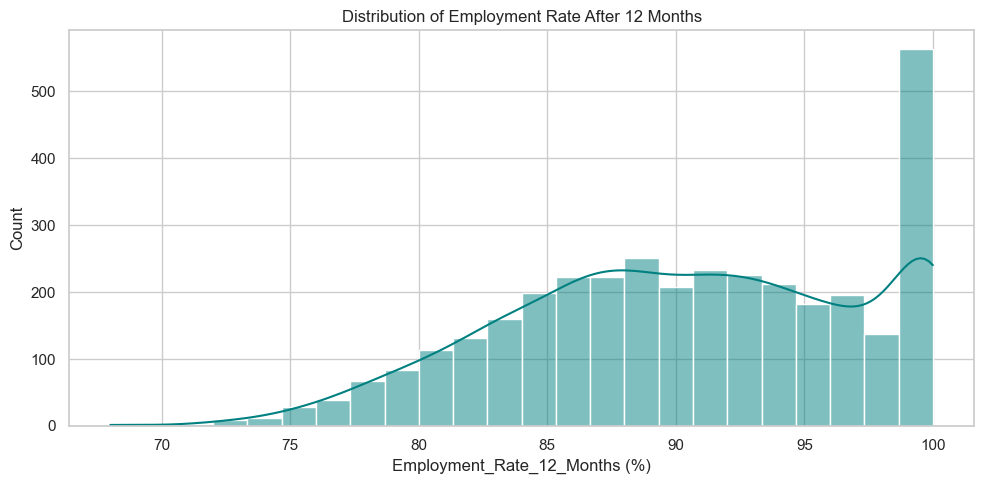

In [9]:
target_column = "Employment_Rate_12_Months (%)"
plt.figure(figsize=(10, 5))
sns.histplot(data[target_column], kde=True, color="teal")
plt.title("Distribution of Employment Rate After 12 Months")
plt.xlabel(target_column)
plt.tight_layout()
plt.show()


### Numeric feature distributions and outliers

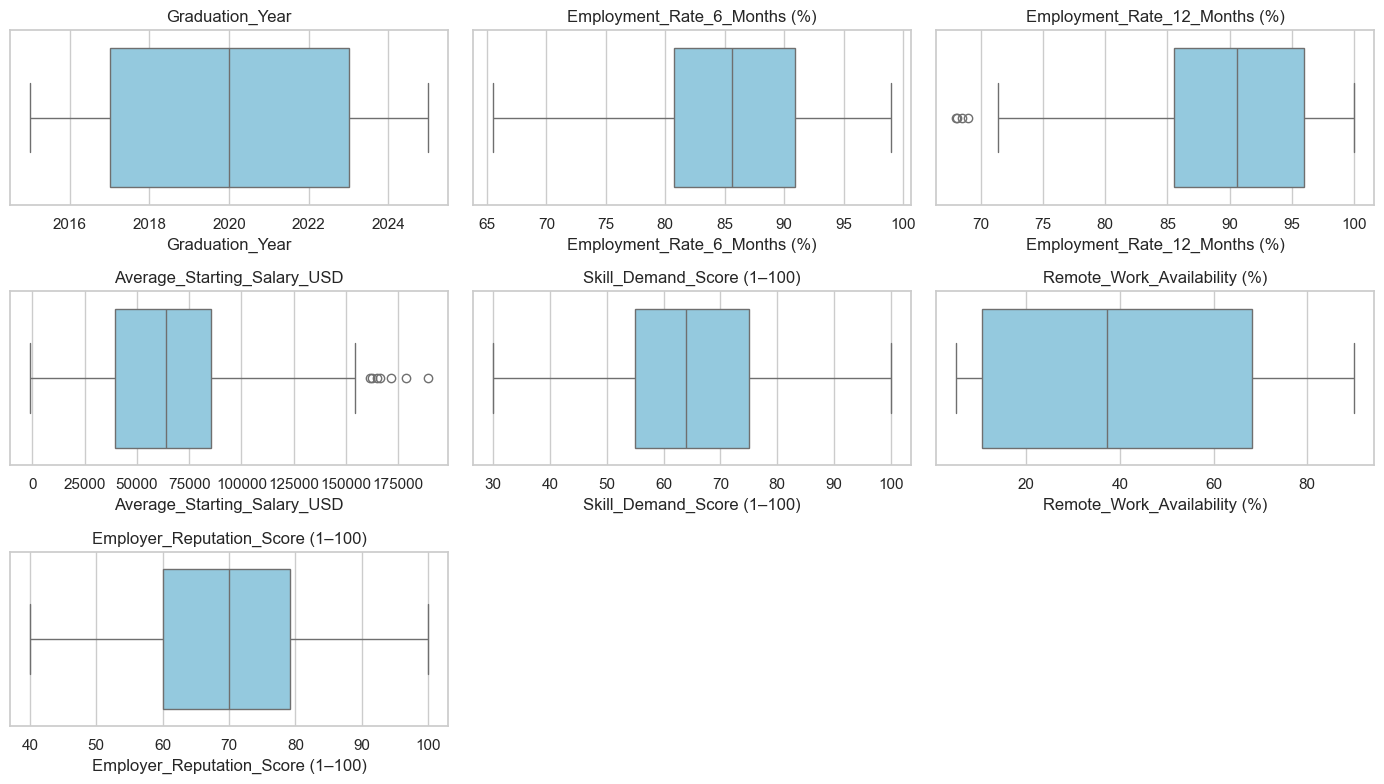

In [10]:
numeric_columns = data.select_dtypes(include=["number"]).columns.tolist()
plt.figure(figsize=(14, 8))
for idx, column in enumerate(numeric_columns, start=1):
    plt.subplot(3, 3, idx)
    sns.boxplot(x=data[column], color="skyblue")
    plt.title(column)
plt.tight_layout()
plt.show()


### Correlations among numeric features

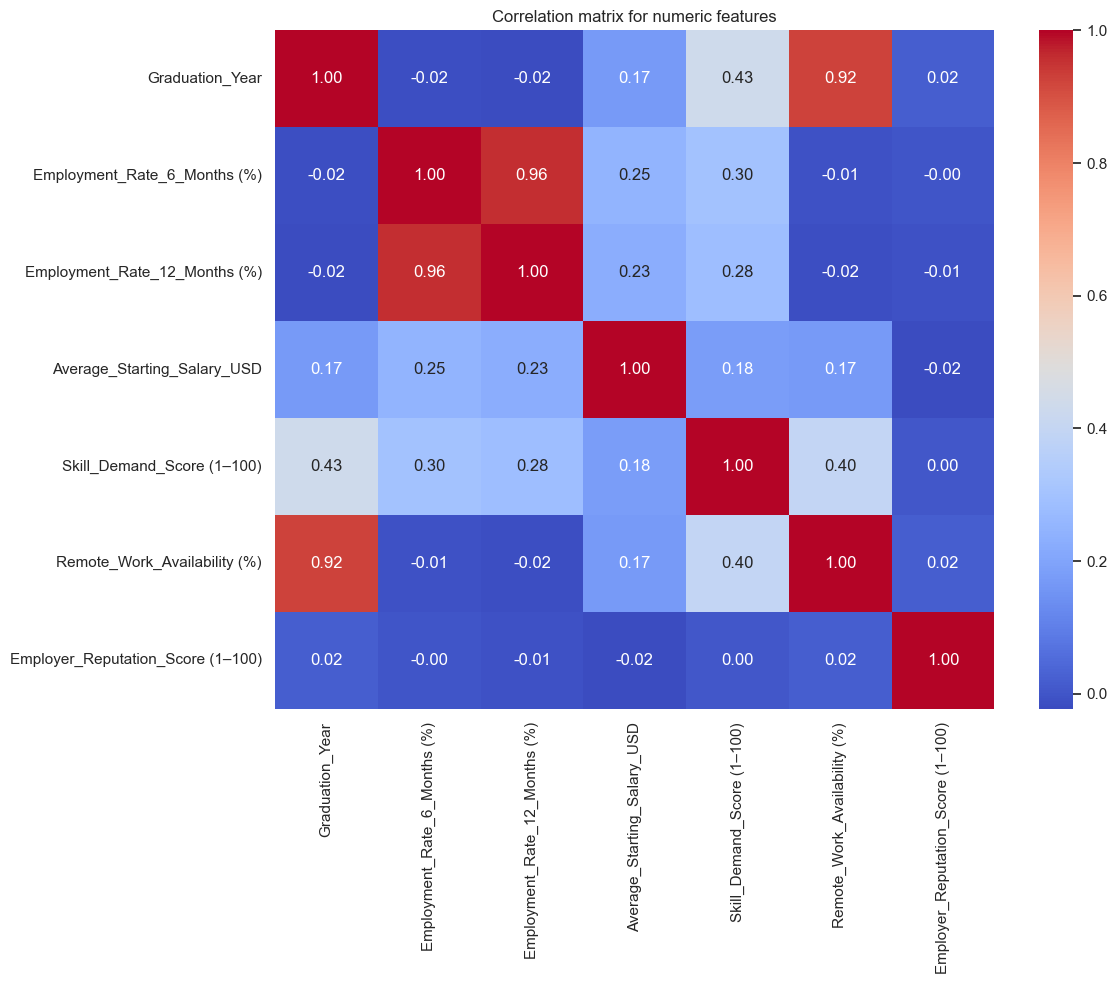

In [11]:
correlation_matrix = data.select_dtypes(include=["number"]).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix for numeric features")
plt.tight_layout()
plt.show()


### Salary by field of study

C:\Users\kinut\AppData\Local\Temp\ipykernel_7504\2384819360.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


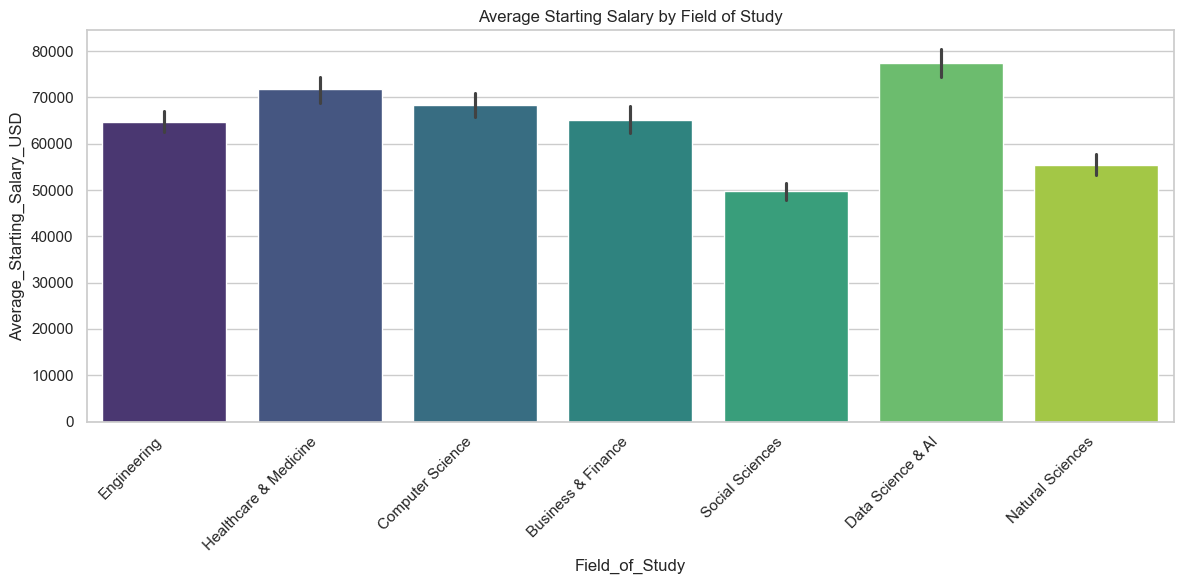

In [12]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=data,
    x="Field_of_Study",
    y="Average_Starting_Salary_USD",
    estimator="mean",
    palette="viridis"
)
plt.xticks(rotation=45, ha="right")
plt.title("Average Starting Salary by Field of Study")
plt.tight_layout()
plt.show()
